<a href="https://colab.research.google.com/github/javageek2018/AirlineArrivalDelay/blob/Modeling/Flights_GradientBoosting_Angela.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
from pyspark.sql.functions import col
import pyspark
import os
from pyspark.sql import SparkSession
from pyspark.sql import Window
from pyspark.sql import functions as F
import shutil, os, glob

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from xgboost.spark import SparkXGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Set Up Spark

In [3]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [4]:
# spark = SparkSession.builder \
#     .appName("ColabSpark") \
#     .master("local[*]") \
#     .config("spark.driver.memory", "8g") \
#     .getOrCreate()

# spark


spark = SparkSession.builder \
    .appName("FlightDelayXGB") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark

# Read Data (Spark)

In [5]:
spark.conf.set("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")
spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")

In [6]:
base_path = "/content/drive/MyDrive/OMDS Capstone/Data/flights_all_features_encoded"

train_file_path = f"{base_path}/train.parquet"
validate_file_path = f"{base_path}/val.parquet"
test_file_path = f"{base_path}/test.parquet"


df_train = spark.read.parquet(train_file_path)
df_val = spark.read.parquet(validate_file_path)
df_test = spark.read.parquet(test_file_path)

In [7]:
print(f"Train: {df_train.count():,} rows")
print(f"Val  : {df_val.count():,} rows")
print(f"Test : {df_test.count():,} rows")

Train: 31,149,502 rows
Val  : 6,743,403 rows
Test : 6,965,246 rows


## Sample the Data

In [8]:
print("📅 Year ranges:")
df_train.select(F.min('Year'), F.max('Year')).show()
df_val.select(F.min('Year'), F.max('Year')).show()
df_test.select(F.min('Year'), F.max('Year')).show()

📅 Year ranges:
+---------+---------+
|min(Year)|max(Year)|
+---------+---------+
|     2018|     2022|
+---------+---------+

+---------+---------+
|min(Year)|max(Year)|
+---------+---------+
|     2023|     2023|
+---------+---------+

+---------+---------+
|min(Year)|max(Year)|
+---------+---------+
|     2024|     2024|
+---------+---------+



In [9]:
SAMPLE_FRACTION = 0.10   # tune based on Colab RAM

# Build stratification key: Year × Month × Class
df_train_keyed = df_train.withColumn(
    'strat_key',
    F.concat_ws('_',
        F.col('Year').cast('string'),
        F.col('Month').cast('string'),
        F.col('ArrDel15').cast('string')
    )
)

# Get all unique strata (5 years × 12 months × 2 classes = 120 strata)
strata = [row['strat_key'] for row in
          df_train_keyed.select('strat_key').distinct().collect()]

print(f"Number of strata: {len(strata)}")

# Same fraction for every stratum
fractions = {s: SAMPLE_FRACTION for s in strata}

# Sample
df_train_sampled = (
    df_train_keyed
    .sampleBy('strat_key', fractions=fractions, seed=42)
    .drop('strat_key')
)

Number of strata: 120


In [10]:
df_train_sampled = df_train_sampled.cache()
df_val_full      = df_val.cache()         # keep val full
df_test_full     = df_test.cache()        # keep test full

# Force materialization (also gives you counts)
train_n = df_train_sampled.count()
val_n   = df_val_full.count()
test_n  = df_test_full.count()

print(f"Train (sampled): {train_n:,}")
print(f"Val   (full 2023): {val_n:,}")
print(f"Test  (full 2024): {test_n:,}")

Train (sampled): 3,115,085
Val   (full 2023): 6,743,403
Test  (full 2024): 6,965,246


In [11]:
# Sample val to ~1M for fast early-stopping evaluation
df_val_sampled = df_val.sampleBy(
    'ArrDel15',
    fractions={0: 0.15, 1: 0.15},   # ~15% → ~1M rows
    seed=42
).cache()

print(f"Val sampled: {df_val_sampled.count():,}")

Val sampled: 1,012,424


## Add Interaction Features

In [14]:
def add_weather_features(df):
    return (df
        # Compounding severe weather (both ends)
        .withColumn('both_severe_weather',
                    F.col('origin_severe_weather') * F.col('dest_severe_weather'))

        # Snow + low visibility = grounding risk
        .withColumn('snow_lowvis_origin',
                    F.col('origin_is_snow') * F.col('origin_low_visibility'))

        # Total weather severity score
        .withColumn('weather_severity_score',
                    F.col('origin_severe_weather') * 3 +
                    F.col('origin_is_snow') * 2 +
                    F.col('origin_is_rain') +
                    F.col('origin_low_visibility') +
                    F.col('origin_high_wind') +
                    F.col('dest_severe_weather') * 3 +
                    F.col('dest_is_snow') * 2)

        # Wind speed × precipitation (storm intensity)
        .withColumn('origin_storm_intensity',
                    F.col('origin_wind_kts') * F.col('origin_precip_in'))
        .withColumn('dest_storm_intensity',
                    F.col('dest_wind_kts') * F.col('dest_precip_in'))
    )

df_train_sampled = add_weather_features(df_train_sampled)
df_val_sampled   = add_weather_features(df_val_sampled)
df_test          = add_weather_features(df_test)

# Train Model

## Define Columns

In [15]:
target = 'ArrDel15'

drop_cols = [
    'FlightDate', 'date',
    'Flight_Number_Reporting_Airline',
    'origin_wx_codes', 'dest_wx_codes',
    target
]

categorical_cols = ['Reporting_Airline', 'Origin', 'Dest', 'DepTimeBlk']

# All numeric columns (everything else except target/drops/categoricals)
all_cols = [c for c, _ in df_train.dtypes]
numeric_cols = [c for c in all_cols if c not in drop_cols + categorical_cols]

In [18]:
def add_interaction_features(df):
    return (df
        .withColumn('hour_x_month',         F.col('dep_hour') * F.col('Month'))
        .withColumn('hour_x_dow',           F.col('dep_hour') * F.col('DayOfWeek'))
        .withColumn('wind_x_rain',          F.col('origin_wind_kts') * F.col('origin_is_rain'))
        .withColumn('lowvis_x_rain',        F.col('origin_low_visibility') * F.col('origin_is_rain'))
        .withColumn('combined_severe',      F.col('origin_severe_weather') + F.col('dest_severe_weather'))
        .withColumn('dep_per_hour_x_hour',  F.col('origin_departures_3h') * F.col('dep_hour'))
        .withColumn('combined_route_risk',  F.col('origin_delay_rate_30d') * F.col('dest_delay_rate_30d'))
        .withColumn('carrier_route_risk',   F.col('carrier_delay_rate_30d') * F.col('origin_delay_rate_30d'))
        .withColumn('holiday_x_hour',       F.col('is_holiday') * F.col('dep_hour'))
        .withColumn('is_longhaul',          (F.col('Distance') > 1500).cast('int'))
    )

df_train_sampled = add_interaction_features(df_train_sampled)
df_val_sampled   = add_interaction_features(df_val_sampled)
df_test          = add_interaction_features(df_test)

# Add to numeric features
NEW_FEATURES = ['hour_x_month', 'hour_x_dow', 'wind_x_rain', 'lowvis_x_rain',
                'combined_severe', 'dep_per_hour_x_hour', 'combined_route_risk',
                'carrier_route_risk', 'holiday_x_hour', 'is_longhaul']
numeric_cols = numeric_cols + NEW_FEATURES
feature_cols = numeric_cols + [f"{c}_idx" for c in categorical_cols]

In [47]:
# Average route delay for each (Origin, Dest) pair — from training data only
route_stats = (
    df_train_sampled
    .groupBy('Origin', 'Dest')
    .agg(
        F.avg(F.col(target).cast('double')).alias('route_delay_rate'),
        F.count('*').alias('route_n_flights')
    )
    .filter(F.col('route_n_flights') >= 30)
)

# Join into all splits
df_train_sampled = df_train_sampled.join(route_stats, ['Origin', 'Dest'], 'left')
df_val_sampled   = df_val_sampled.join(route_stats, ['Origin', 'Dest'], 'left')
df_test          = df_test.join(route_stats, ['Origin', 'Dest'], 'left')

# Fill nulls with global mean (for unseen routes)
global_rate = df_train_sampled.agg(F.avg(target)).collect()[0][0]
for d in [df_train_sampled, df_val_sampled, df_test]:
    d = d.fillna({'route_delay_rate': global_rate, 'route_n_flights': 0})

# Add to NUMERIC_COLS
numeric_cols += ['route_delay_rate', 'route_n_flights']
FEATURE_COLS = numeric_cols + [f"{c}_idx" for c in categorical_cols]

In [48]:
df_train_sampled.dtypes

[('Origin', 'string'),
 ('Dest', 'string'),
 ('Year', 'double'),
 ('Quarter', 'double'),
 ('Month', 'double'),
 ('DayofMonth', 'double'),
 ('DayOfWeek', 'double'),
 ('FlightDate', 'bigint'),
 ('Reporting_Airline', 'string'),
 ('Flight_Number_Reporting_Airline', 'string'),
 ('CRSDepTime', 'double'),
 ('DepTimeBlk', 'string'),
 ('CRSArrTime', 'double'),
 ('ArrDel15', 'int'),
 ('CRSElapsedTime', 'double'),
 ('Distance', 'double'),
 ('DistanceGroup', 'double'),
 ('date', 'string'),
 ('dep_hour', 'double'),
 ('arr_hour', 'double'),
 ('dep_hour_minus2', 'double'),
 ('arr_hour_minus2', 'double'),
 ('origin_temp_f', 'double'),
 ('origin_dewpoint_f', 'double'),
 ('origin_humidity', 'double'),
 ('origin_feels_like_f', 'double'),
 ('origin_wind_kts', 'double'),
 ('origin_gust_kts', 'double'),
 ('origin_visibility', 'double'),
 ('origin_precip_in', 'double'),
 ('origin_wx_codes', 'string'),
 ('origin_is_rain', 'double'),
 ('origin_is_snow', 'double'),
 ('origin_is_fog', 'double'),
 ('origin_low_vi

## Check for NULLs and Cast Target

In [49]:
total = df_train_sampled.count()
null_row = df_train_sampled.select([
    F.sum(F.col(c).isNull().cast('int')).alias(c)
    for c in numeric_cols
]).collect()[0].asDict()

nulls_found = {c: n for c, n in null_row.items() if n > 0}

if not nulls_found:
    print("✅ No nulls in any numeric column.")
else:
    print(f"⚠️ {len(nulls_found)} columns with nulls:")
    for c, n in sorted(nulls_found.items(), key=lambda x: -x[1]):
        print(f"  {c:<35} {n:>10,}  ({100*n/total:.2f}%)")

⚠️ 2 columns with nulls:
  route_delay_rate                        20,284  (0.65%)
  route_n_flights                         20,284  (0.65%)


In [51]:
def prep(df):
    # Cast target to int (XGBoost requires integer labels for classification)
    df = df.withColumn(target, F.col(target).cast('int'))

    # Cast all numeric features to double for VectorAssembler consistency
    for c in numeric_cols:
        df = df.withColumn(c, F.col(c).cast('double'))

    return df

df_train_sampled = prep(df_train_sampled)
df_val_sampled   = prep(df_val_sampled)
df_test  = prep(df_test)

## Index Categoricals (Spark ML)

In [52]:
# XGBoost handles integer-encoded categoricals well, and one-hot explodes dimensionality

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid='keep'   # unseen categories → extra bucket
    )
    for c in categorical_cols
]

## Assemble Feature Vector

In [64]:
# Fill any nulls with 0 for all numeric features
df_train_sampled = df_train_sampled.fillna(0.0, subset=numeric_cols)
df_val_sampled   = df_val_sampled.fillna(0.0,   subset=numeric_cols)
df_test          = df_test.fillna(0.0,          subset=numeric_cols)

# Then VectorAssembler can use strict mode
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='features',
    handleInvalid='error'
)

In [65]:
feature_cols = numeric_cols + [f"{c}_idx" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features',
    handleInvalid='keep'
)

## Calculate Hyperparameter for Class Imbalance


In [58]:
counts = df_train_sampled.groupBy(target).count().collect()
counts_dict = {row[target]: row['count'] for row in counts}
# scale_pos_weight = math.sqrt(counts_dict[0] / counts_dict[1])
scale_pos_weight = 1 # makes the model more conservative
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 1.00


In [59]:
# Year distribution
print("📅 Sampled train by year:")
df_train_sampled.groupBy('Year').count().orderBy('Year').show()

# Month distribution
print("📆 Sampled train by month:")
df_train_sampled.groupBy('Month').count().orderBy('Month').show()

# Compare delay rates: original vs sample
orig_rate = df_train.filter(F.col('ArrDel15')==1).count() / df_train.count()
samp_rate = counts_dict[1] / (counts_dict[0] + counts_dict[1])

print(f"\nOriginal delay rate: {orig_rate:.4f}")
print(f"Sample   delay rate: {samp_rate:.4f}")
print(f"Diff               : {abs(orig_rate - samp_rate)*100:.3f}%  ← should be < 0.1%")

📅 Sampled train by year:
+------+------+
|  Year| count|
+------+------+
|2018.0|706224|
|2019.0|726580|
|2020.0|440338|
|2021.0|588201|
|2022.0|653742|
+------+------+

📆 Sampled train by month:
+-----+------+
|Month| count|
+-----+------+
|  1.0|258429|
|  2.0|238633|
|  3.0|273950|
|  4.0|235476|
|  5.0|245792|
|  6.0|253898|
|  7.0|277862|
|  8.0|277629|
|  9.0|257382|
| 10.0|270635|
| 11.0|261592|
| 12.0|263807|
+-----+------+


Original delay rate: 0.1785
Sample   delay rate: 0.1788
Diff               : 0.027%  ← should be < 0.1%


## Configure Spark XGBoost Classifier

In [66]:
xgb_clf = SparkXGBClassifier(
    features_col='features',
    label_col=target,
    prediction_col='prediction',
    probability_col='probability',
    raw_prediction_col='rawPrediction',

    # Hyperparameters
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.05,
    #reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    tree_method='hist',
    max_bin=256,

    # Distributed training
    num_workers=1,           # set to # of Spark executors
    device='cuda',            # or 'cuda' for GPU
    early_stopping_rounds=100,
    validation_indicator_col='is_val'
)

## Combine Train + Val for Early Stopping

In [67]:
# df_train_marked = df_train.withColumn('is_val', F.lit(False))
# df_val_marked   = df_val.withColumn('is_val', F.lit(True))
# df_trainval     = df_train_marked.unionByName(df_val_marked)

# Use SAMPLED val for early stopping (faster)
# Or use df_val_full if you have RAM headroom

df_train_marked = df_train_sampled.withColumn('is_val', F.lit(False))
df_val_marked   = df_val_sampled.withColumn('is_val', F.lit(True))   # or df_val_full

df_trainval = df_train_marked.unionByName(df_val_marked).repartition(8).cache()

print(f"Combined train+val: {df_trainval.count():,}")
print(f"Train rows: {df_trainval.filter(~F.col('is_val')).count():,}")
print(f"Val   rows: {df_trainval.filter( F.col('is_val')).count():,}")

Combined train+val: 4,127,509
Train rows: 3,115,085
Val   rows: 1,012,424


## Build and Fit Pipeline

In [68]:
pipeline = Pipeline(stages=indexers + [assembler, xgb_clf])

model = pipeline.fit(df_trainval)
print("✅ Training complete")

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'auc', 'gamma': 0.05, 'learning_rate': 0.03, 'max_bin': 256, 'max_depth': 10, 'min_child_weight': 3, 'reg_lambda': 1.0, 'scale_pos_weight': 1, 'subsample': 0.8, 'tree_method': 'hist', 'nthread': 1}
	train_call_kwargs_params: {'early_stopping_rounds': 100, 'verbose_eval': True, 'num_boost_round': 3000}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


✅ Training complete


# Evaluate on Validation Set

In [69]:
preds = model.transform(df_val_sampled)

# ROC-AUC & PR-AUC
auc_eval = BinaryClassificationEvaluator(
    labelCol=target, rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)
pr_eval = BinaryClassificationEvaluator(
    labelCol=target, rawPredictionCol='rawPrediction', metricName='areaUnderPR'
)

print(f"ROC-AUC: {auc_eval.evaluate(preds):.4f}")
print(f"PR-AUC : {pr_eval.evaluate(preds):.4f}")

# Accuracy / F1
acc_eval = MulticlassClassificationEvaluator(
    labelCol=target, predictionCol='prediction', metricName='accuracy'
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol=target, predictionCol='prediction', metricName='f1'
)
print(f"Accuracy: {acc_eval.evaluate(preds):.4f}")
print(f"F1      : {f1_eval.evaluate(preds):.4f}")

# Confusion matrix
preds.groupBy(target, 'prediction').count().orderBy(target, 'prediction').show()

ROC-AUC: 0.7108
PR-AUC : 0.4068
Accuracy: 0.8003
F1      : 0.7490
+--------+----------+------+
|ArrDel15|prediction| count|
+--------+----------+------+
|       0|       0.0|781125|
|       0|       1.0| 22507|
|       1|       0.0|179626|
|       1|       1.0| 29166|
+--------+----------+------+



## Confusion Matrix

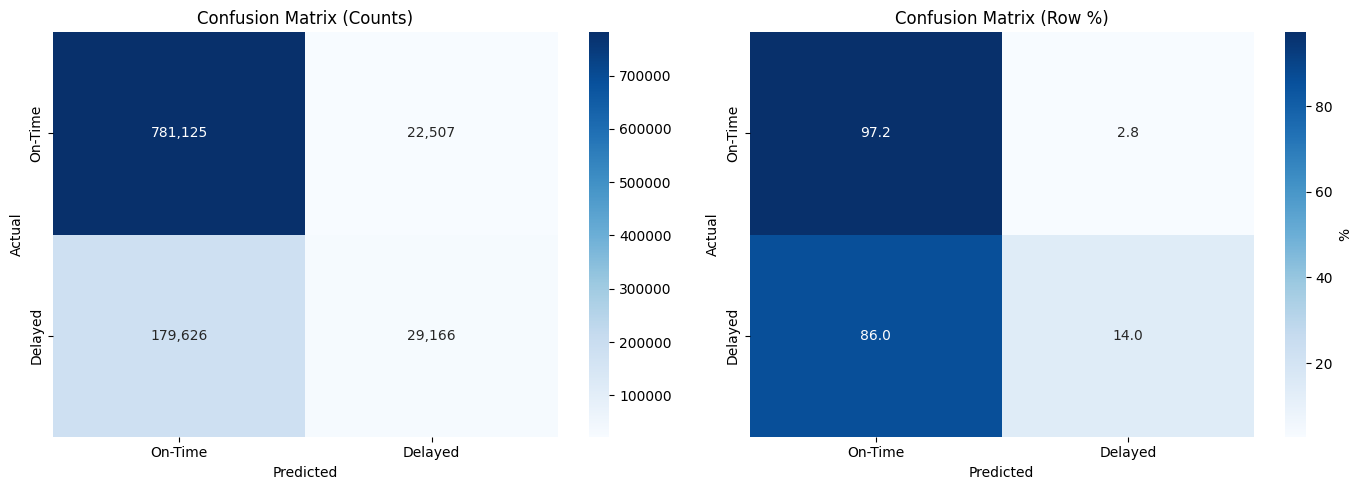

In [70]:
cm_pd = (preds.groupBy(target, 'prediction').count()
              .toPandas()
              .pivot(index=target, columns='prediction', values='count')
              .fillna(0).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm_pd, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Row-normalized (recall view)
cm_pct = cm_pd.div(cm_pd.sum(axis=1), axis=0) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'],
            cbar_kws={'label': '%'})
axes[1].set_title('Confusion Matrix (Row %)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Threshold Tuning (Spark Side)

In [71]:
from pyspark.sql.types import DoubleType

# Extract P(class=1) from probability vector
extract_p1 = F.udf(lambda v: float(v[1]), DoubleType())
preds_with_p = preds.withColumn('p1', extract_p1('probability'))

# Sweep thresholds
import numpy as np
results = []
for t in np.arange(0.2, 0.8, 0.05):
    tp = preds_with_p.filter((F.col('p1') >= t) & (F.col(target) == 1)).count()
    fp = preds_with_p.filter((F.col('p1') >= t) & (F.col(target) == 0)).count()
    fn = preds_with_p.filter((F.col('p1') <  t) & (F.col(target) == 1)).count()
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    results.append((round(t,2), prec, rec, f1))

for r in results:
    print(f"thr={r[0]:.2f} | P={r[1]:.3f} | R={r[2]:.3f} | F1={r[3]:.3f}")

thr=0.20 | P=0.331 | R=0.648 | F1=0.438
thr=0.25 | P=0.373 | R=0.525 | F1=0.436
thr=0.30 | P=0.414 | R=0.420 | F1=0.417
thr=0.35 | P=0.452 | R=0.331 | F1=0.382
thr=0.40 | P=0.490 | R=0.256 | F1=0.336
thr=0.45 | P=0.528 | R=0.192 | F1=0.282
thr=0.50 | P=0.564 | R=0.140 | F1=0.224
thr=0.55 | P=0.601 | R=0.097 | F1=0.167
thr=0.60 | P=0.643 | R=0.064 | F1=0.117
thr=0.65 | P=0.685 | R=0.040 | F1=0.076
thr=0.70 | P=0.730 | R=0.023 | F1=0.045
thr=0.75 | P=0.771 | R=0.012 | F1=0.024
thr=0.80 | P=0.811 | R=0.005 | F1=0.011


## Feature Importance

In [72]:
xgb_model = model.stages[-1]
booster = xgb_model.get_booster()
importance = booster.get_score(importance_type='gain')

# Map integer-string keys to feature names
imp_named = sorted(
    [(feature_cols[int(k)], v) for k, v in importance.items()],
    key=lambda x: -x[1]
)

print(f"{'Feature':<40}{'Gain':>12}")
print("-" * 52)
for feat, score in imp_named[:25]:
    print(f"{feat:<40}{score:>12.2f}")

Feature                                         Gain
----------------------------------------------------
combined_severe                               338.29
combined_severe                               239.00
arr_hour_minus2                               177.77
origin_is_snow                                158.75
dep_hour_minus2                               105.35
carrier_route_risk                             62.81
carrier_route_risk                             36.51
combined_route_risk                            33.63
combined_route_risk                            32.79
origin_low_visibility                          27.51
origin_precip_in                               25.85
CRSDepTime                                     23.58
Month                                          22.78
route_delay_rate                               22.16
Reporting_Airline_idx                          20.59
Quarter                                        20.47
carrier_delay_rate_30d                        

In [73]:
# How many features actually used vs total?
used_features = len(importance)
total_features = len(feature_cols)
print(f"Used: {used_features} / {total_features} ({100*used_features/total_features:.1f}%)")

# Show ALL features sorted (including unused)
all_imp = {f: 0.0 for f in feature_cols}
for k, v in importance.items():
    all_imp[feature_cols[int(k)]] = v

sorted_all = sorted(all_imp.items(), key=lambda x: -x[1])
print("\nAll features ranked:")
for f, s in sorted_all:
    bar = '█' * int(s / 5) if s > 0 else ''
    print(f"  {f:<35}{s:>10.2f}  {bar}")

Used: 81 / 81 (100.0%)

All features ranked:
  combined_severe                        239.00  ███████████████████████████████████████████████
  arr_hour_minus2                        177.77  ███████████████████████████████████
  origin_is_snow                         158.75  ███████████████████████████████
  dep_hour_minus2                        105.35  █████████████████████
  carrier_route_risk                      62.81  ████████████
  combined_route_risk                     32.79  ██████
  origin_low_visibility                   27.51  █████
  origin_precip_in                        25.85  █████
  CRSDepTime                              23.58  ████
  Month                                   22.78  ████
  route_delay_rate                        22.16  ████
  Reporting_Airline_idx                   20.59  ████
  Quarter                                 20.47  ████
  carrier_delay_rate_30d                  18.65  ███
  is_holiday                              18.46  ███
  Year           

In [74]:
# Check correlation between dep_hour and dep_hour_minus2
df_train_sampled.select(
    F.corr('dep_hour', 'dep_hour_minus2').alias('correlation')
).show()

+------------------+
|       correlation|
+------------------+
|0.9649260576094986|
+------------------+



In [75]:
# Are the historical delay rates really computed correctly?
df_train_sampled.select(
    F.mean('carrier_delay_rate_30d').alias('carrier_30d_mean'),
    F.stddev('carrier_delay_rate_30d').alias('carrier_30d_std'),
    F.mean('origin_delay_rate_30d').alias('origin_30d_mean'),
    F.mean('dest_delay_rate_30d').alias('dest_30d_mean'),
).show()

# Check for null/zero variance
df_train_sampled.select(
    F.sum(F.col('carrier_delay_rate_30d').isNull().cast('int')).alias('carrier_nulls'),
    F.sum(F.col('origin_delay_rate_30d').isNull().cast('int')).alias('origin_nulls'),
).show()

+-------------------+-------------------+------------------+-------------------+
|   carrier_30d_mean|    carrier_30d_std|   origin_30d_mean|      dest_30d_mean|
+-------------------+-------------------+------------------+-------------------+
|0.17802693569729702|0.06707280514869864|0.1779885263685378|0.17808574337801977|
+-------------------+-------------------+------------------+-------------------+

+-------------+------------+
|carrier_nulls|origin_nulls|
+-------------+------------+
|            0|           0|
+-------------+------------+



In [76]:
# Check correlations
df_train_sampled.select(
    F.corr('origin_delay_rate', 'origin_delay_rate_30d').alias('orig_vs_30d'),
    F.corr('origin_delay_rate', 'origin_delay_rate_90d').alias('orig_vs_90d'),
    F.corr('origin_delay_rate_30d', 'origin_delay_rate_90d').alias('30d_vs_90d'),
).show()

+------------------+------------------+------------------+
|       orig_vs_30d|       orig_vs_90d|        30d_vs_90d|
+------------------+------------------+------------------+
|0.4663873596184891|0.5642609114229976|0.8559726728983929|
+------------------+------------------+------------------+



## Optimize Threshold

In [77]:
OPTIMAL_THRESHOLD = 0.20

preds_final = preds_with_p.withColumn(
    'final_prediction',
    (F.col('p1') >= OPTIMAL_THRESHOLD).cast('double')
)

# Confusion matrix at chosen threshold
preds_final.groupBy(target, 'final_prediction').count().orderBy(target, 'final_prediction').show()

+--------+----------------+------+
|ArrDel15|final_prediction| count|
+--------+----------------+------+
|       0|             0.0|530584|
|       0|             1.0|273048|
|       1|             0.0| 73512|
|       1|             1.0|135280|
+--------+----------------+------+



In [78]:
for t in np.arange(0.10, 0.30, 0.02):
    tp = preds_with_p.filter((F.col('p1') >= t) & (F.col(target) == 1)).count()
    fp = preds_with_p.filter((F.col('p1') >= t) & (F.col(target) == 0)).count()
    fn = preds_with_p.filter((F.col('p1') <  t) & (F.col(target) == 1)).count()
    tn = preds_with_p.filter((F.col('p1') <  t) & (F.col(target) == 0)).count()

    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    f1 = 2*prec*rec/(prec+rec+1e-9); acc = (tp+tn)/(tp+fp+fn+tn)
    print(f"thr={t:.2f} | P={prec:.3f} | R={rec:.3f} | F1={f1:.3f} | Acc={acc:.3f}")

thr=0.10 | P=0.244 | R=0.915 | F1=0.385 | Acc=0.397
thr=0.12 | P=0.260 | R=0.865 | F1=0.400 | Acc=0.466
thr=0.14 | P=0.278 | R=0.812 | F1=0.414 | Acc=0.527
thr=0.16 | P=0.296 | R=0.756 | F1=0.425 | Acc=0.579
thr=0.18 | P=0.314 | R=0.701 | F1=0.433 | Acc=0.622
thr=0.20 | P=0.331 | R=0.648 | F1=0.438 | Acc=0.658
thr=0.22 | P=0.349 | R=0.597 | F1=0.440 | Acc=0.687
thr=0.24 | P=0.365 | R=0.548 | F1=0.438 | Acc=0.710
thr=0.26 | P=0.381 | R=0.503 | F1=0.434 | Acc=0.729
thr=0.28 | P=0.398 | R=0.460 | F1=0.427 | Acc=0.745


In [79]:
T = 0.22  # your chosen operating point
tp = preds_with_p.filter((F.col('p1') >= T) & (F.col(target) == 1)).count()
fp = preds_with_p.filter((F.col('p1') >= T) & (F.col(target) == 0)).count()
fn = preds_with_p.filter((F.col('p1') <  T) & (F.col(target) == 1)).count()
tn = preds_with_p.filter((F.col('p1') <  T) & (F.col(target) == 0)).count()

prec = tp/(tp+fp); rec = tp/(tp+fn)
spec = tn/(tn+fp); f1 = 2*prec*rec/(prec+rec)
acc = (tp+tn)/(tp+fp+fn+tn)

print(f"\n=== FINAL METRICS @ threshold={T} ===")
print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"Specificity: {spec:.4f}")
print(f"F1         : {f1:.4f}")
print(f"\nCaught {tp:,} of {tp+fn:,} delays ({rec*100:.1f}%)")
print(f"Falsely flagged {fp:,} on-time flights ({fp/(fp+tn)*100:.1f}% FPR)")


=== FINAL METRICS @ threshold=0.22 ===
Accuracy   : 0.6869
Precision  : 0.3487
Recall     : 0.5971
Specificity: 0.7102
F1         : 0.4402

Caught 124,671 of 208,792 delays (59.7%)
Falsely flagged 232,908 on-time flights (29.0% FPR)


## Audit Features

In [80]:
def audit_model_features(model, target_features):
    """Audit whether specific features are used by the trained model."""

    # Find the VectorAssembler specifically (not StringIndexers)
    from pyspark.ml.feature import VectorAssembler

    assembler = None
    for s in model.stages:
        if isinstance(s, VectorAssembler):
            assembler = s
            break

    if assembler is None:
        print("❌ No VectorAssembler found in pipeline")
        return

    actual_features = assembler.getInputCols()

    # Get XGBoost importance
    booster = model.stages[-1].get_booster()
    importance = booster.get_score(importance_type='gain')

    used_indices = {int(k) for k in importance.keys()}
    feature_gain = {actual_features[int(k)]: v for k, v in importance.items()}

    # Report
    print("=" * 70)
    print(f"FEATURE AUDIT — checking {len(target_features)} features")
    print("=" * 70)
    print(f"{'Feature':<35}{'In Model':<11}{'Used':<8}{'Gain':>12}")
    print("-" * 70)

    for f in target_features:
        in_model = f in actual_features
        if in_model:
            idx = actual_features.index(f)
            used = idx in used_indices
            gain = feature_gain.get(f, 0.0)
            print(f"{f:<35}{'✅':<11}{'✅' if used else '❌':<8}{gain:>12.2f}")
        else:
            print(f"{f:<35}{'❌':<11}{'-':<8}{'-':>12}")

    print(f"\nTotal model features : {len(actual_features)}")
    print(f"Features used        : {len(used_indices)}")
    print(f"Features ignored     : {len(actual_features) - len(used_indices)}")

# Usage
audit_model_features(model, [
    'origin_delay_rate',
    'dest_delay_rate',
    'origin_delay_rate_30d',
    'origin_delay_rate_90d',
    'dest_delay_rate_30d',
    'dest_delay_rate_90d',
    'carrier_delay_rate_30d',
    'carrier_delay_rate_90d',
])

FEATURE AUDIT — checking 8 features
Feature                            In Model   Used            Gain
----------------------------------------------------------------------
origin_delay_rate                  ✅          ✅               9.60
dest_delay_rate                    ✅          ✅              10.99
origin_delay_rate_30d              ✅          ✅               8.81
origin_delay_rate_90d              ✅          ✅               8.71
dest_delay_rate_30d                ✅          ✅              10.26
dest_delay_rate_90d                ✅          ✅               9.19
carrier_delay_rate_30d             ✅          ✅              18.65
carrier_delay_rate_90d             ✅          ✅              10.93

Total model features : 81
Features used        : 81
Features ignored     : 0
